In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/train_scaled.csv")

max_cycle = df.groupby("engine_id")["cycle"].transform("max")

df["life_ratio"] = df["cycle"] / max_cycle

sensor_cols = [c for c in df.columns if "sensor" in c]

## added life_ratio to give temporal context to the data point
# features = sensor_cols + ["cycle", "life_ratio"]

top_sensors = [
"sensor_11","sensor_9","sensor_4","sensor_12","sensor_7",
"sensor_14","sensor_15","sensor_21","sensor_2","sensor_13"
]

# X = df[features]
# y = df["RUL"]

X = df[top_sensors]
y = df["RUL"]

In [3]:
# train / test split using engine id to avoid data leakage...
from sklearn.model_selection import train_test_split

engine_ids = df.engine_id.unique()

train_ids, test_ids = train_test_split(engine_ids, test_size=0.2, random_state=42)

train_df = df[df.engine_id.isin(train_ids)]
test_df = df[df.engine_id.isin(test_ids)]

# X_train = train_df[sensor_cols]
# y_train = train_df["RUL"]

# X_test = test_df[sensor_cols]
# y_test = test_df["RUL"]

X_train = train_df[top_sensors]
y_train = train_df["RUL"]

X_test = test_df[top_sensors]
y_test = test_df["RUL"]

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))

print("Linear Regression MAE:", mae_lr)
print("Linear Regression RMSE:", rmse_lr)

Linear Regression MAE: 16.592927839826196
Linear Regression RMSE: 20.50798569117112


In [6]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

mae_rf_baseline = mean_absolute_error(y_test, pred_rf)
rmse_rf_baseline = np.sqrt(mean_squared_error(y_test, pred_rf))

print("Random Forest MAE:", mae_rf_baseline)
print("Random Forest RMSE:", rmse_rf_baseline)

Random Forest MAE: 12.478526471803592
Random Forest RMSE: 17.146872214638947


In [7]:
print("Model Comparison")
print("----------------")
print("Linear Regression RMSE:", rmse_lr)
print("Random Forest RMSE:", rmse_rf_baseline)

Model Comparison
----------------
Linear Regression RMSE: 20.50798569117112
Random Forest RMSE: 17.146872214638947


In [ ]:
# BASELINE Model Comparison 
# ----------------
# Linear Regression RMSE: 20.40611783821649
# Random Forest RMSE: 17.02335221728995

# linear regression on average predicts off by ~ 20 cycle
# random forest on average predicts off by ~ 17 cycle
# since we had made sure RUL - [0,125] so its kinda reasonable


# 1 fact to note - since linear regression asssumes linear relationship but degradation is obviously non-linear, so random forest should have performed better (its doing so but still the difference should have been a bit more ig)

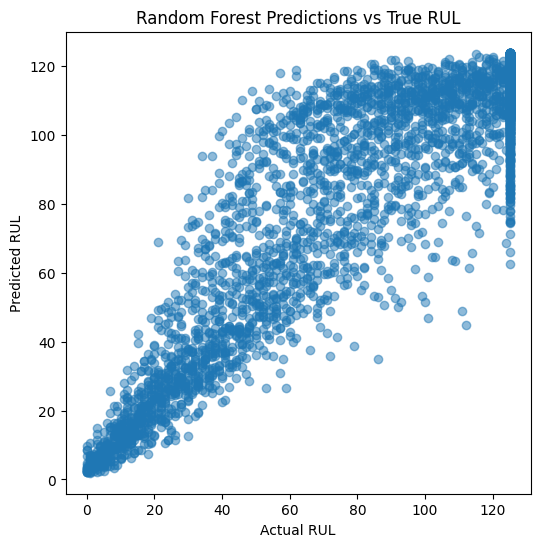

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_rf, alpha=0.5)
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Random Forest Predictions vs True RUL")
plt.show()

In [ ]:
# Adding cycle based degradation features did not significantly improve performance, maybe because the sensor measurements already implicitly encoded the engine’s degradation state.

In [11]:
# tuning the hyper-parameters of random forest

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [10, 15, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

# Fitting 3 folds for each of 24 candidates, totalling 72 fits
# Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 400}



Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 400}


In [12]:
# training with best parameters
best_rf = RandomForestRegressor(
    **grid.best_params_,
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [13]:
from sklearn.metrics import mean_squared_error
import numpy as np

pred_rf = best_rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))

print("Tuned Random Forest RMSE:", rmse_rf)

Tuned Random Forest RMSE: 17.148708191519884


In [14]:
print("Linear Regression RMSE:", rmse_lr)
print("Baseline RF RMSE:", rmse_rf_baseline)
print("Tuned RF RMSE:", rmse_rf)

Linear Regression RMSE: 20.50798569117112
Baseline RF RMSE: 17.146872214638947
Tuned RF RMSE: 17.148708191519884


In [ ]:
# Linear Regression RMSE: 20.40611783821649
# Baseline RF RMSE: 17.02335221728995
# Tuned RF RMSE: 17.006485571786786

# tuning the RF didn't help maybe because - RF is already at its capacity on this feature representation

In [ ]:
# TRYING TO IMRPOVE BASELINES USING - TREE models to tell which sensors influence the predictions most...
# using random forest feature importance to identify the most influential sensors for predicting RUL

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

importances = best_rf.feature_importances_

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

print(feature_importance)


#       feature  importance
# 8   sensor_11    0.644878
# 7    sensor_9    0.137168
# 2    sensor_4    0.081520
# 9   sensor_12    0.029373
# 5    sensor_7    0.022112
# 11  sensor_14    0.020875
# 12  sensor_15    0.014343
# 16  sensor_21    0.009648
# 0    sensor_2    0.008491
# 10  sensor_13    0.008355
# 1    sensor_3    0.007434
# 15  sensor_20    0.007382
# 6    sensor_8    0.005825
# 14  sensor_17    0.002587
# 4    sensor_6    0.000008
# 3    sensor_5    0.000000
# 13  sensor_16    0.000000

     feature  importance
0  sensor_11    0.648793
1   sensor_9    0.139189
2   sensor_4    0.084179
3  sensor_12    0.031895
4   sensor_7    0.024304
5  sensor_14    0.022442
6  sensor_15    0.016563
7  sensor_21    0.011676
9  sensor_13    0.010614
8   sensor_2    0.010345


In [16]:
import json

top_sensors = feature_importance["feature"].head(10).tolist()

with open("../data/processed/top_sensors.json", "w") as f:
    json.dump(top_sensors, f)

print("Saved sensors:", top_sensors)

Saved sensors: ['sensor_11', 'sensor_9', 'sensor_4', 'sensor_12', 'sensor_7', 'sensor_14', 'sensor_15', 'sensor_21', 'sensor_13', 'sensor_2']


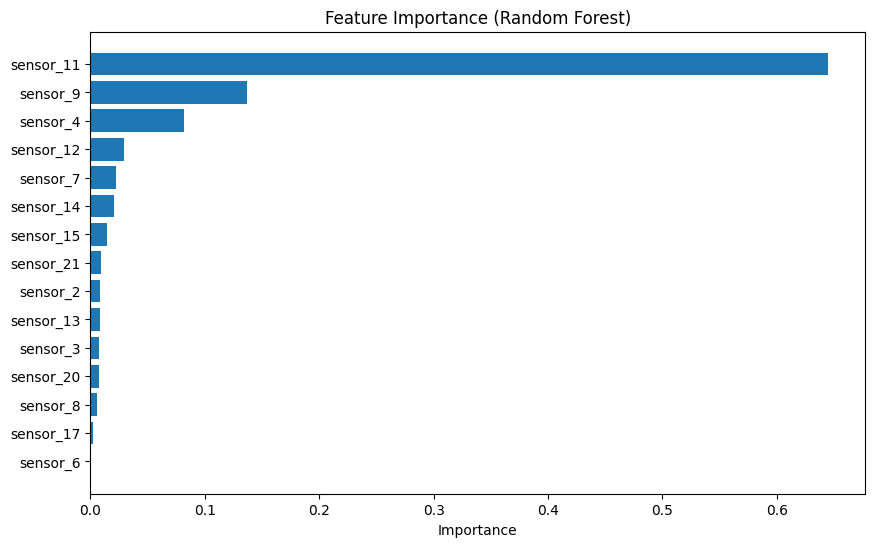

In [30]:
# plotting the importance
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["feature"][:15],
    feature_importance["importance"][:15]
)

plt.gca().invert_yaxis()
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

In [53]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train, y_train)

pred_gbr = gbr.predict(X_test)

rmse_gbr = np.sqrt(mean_squared_error(y_test, pred_gbr))

print("Gradient Boosting RMSE:", rmse_gbr)

Gradient Boosting RMSE: 17.090830879666143


In [54]:
print("Model Comparison")
print("------------------")
print("Linear Regression RMSE:", rmse_lr)
print("Random Forest:", rmse_rf)
print("Gradient Boosting:", rmse_gbr)
print("Baseline RF RMSE:", rmse_rf_baseline)


Model Comparison
------------------
Linear Regression RMSE: 20.50798569117112
Random Forest: 17.148708191519884
Gradient Boosting: 17.090830879666143
Baseline RF RMSE: 17.146872214638947


In [ ]:
# even after identification of important sensor, hyper-parameter tuning and using gradient boosting the performace couldn't be improved beyond ~17 so we might have actually hit the 
# plateau.. since the data itself is inherently temporal and using single row for prediction is questionable. so next we will try some temporal models...